In [1]:
import joblib
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from rasterio.transform import from_origin
from matplotlib.colors import ListedColormap

## Prepare Dataset Prediksi

In [4]:
# Load Sentinel image
sentinel_image_path = "E:\\Folu Net Sink 2030\\Citra\\Sentinel-2\\Sentinel-2A_IKN_Median_2024.tif"  # Ganti dengan path citra Sentinel Anda
with rasterio.open(sentinel_image_path) as src:
    bands = []
    for i in range(1, 5):  # Mengambil 4 band pertama
        bands.append(src.read(i))
    sentinel_data = np.stack(bands, axis=-1)
    metadata = src.meta  # Simpan metadata citra asli

# Reshape data for prediction
original_shape = sentinel_data.shape[:2]
data_flatten = sentinel_data.reshape(-1, 4)

In [3]:
# Load trained models
model_rf = joblib.load("rf_model_osm.joblib")
model_svm = joblib.load("svm_model_osm.joblib")
model_gb = joblib.load("GB_model_osm.joblib")
model_nb = joblib.load("nb_model_osm.joblib")

In [6]:
# Custom colormap untuk biner
binary_cmap = ListedColormap(["white", "Green"])  # 0 = white, 1 = black

# Visualisasi hasil prediksi
def visualize_prediction(title, prediction):
    plt.figure(figsize=(10, 8))
    plt.title(title)
    im = plt.imshow(prediction, cmap=binary_cmap)  # Gunakan custom colormap
    cbar = plt.colorbar(im, ticks=[0, 1])
    cbar.set_ticklabels(["Non-Wooded", "Wooded"])  # Ganti label colorbar
    cbar.set_label("Land Cover Class", fontsize=12)
    plt.show()

## Random Forest

In [5]:
# Prediksi menggunakan model
predictions_rf = model_rf.predict(data_flatten)

# Reshape hasil prediksi ke dimensi asli citra
pred_rf = predictions_rf.reshape(original_shape)

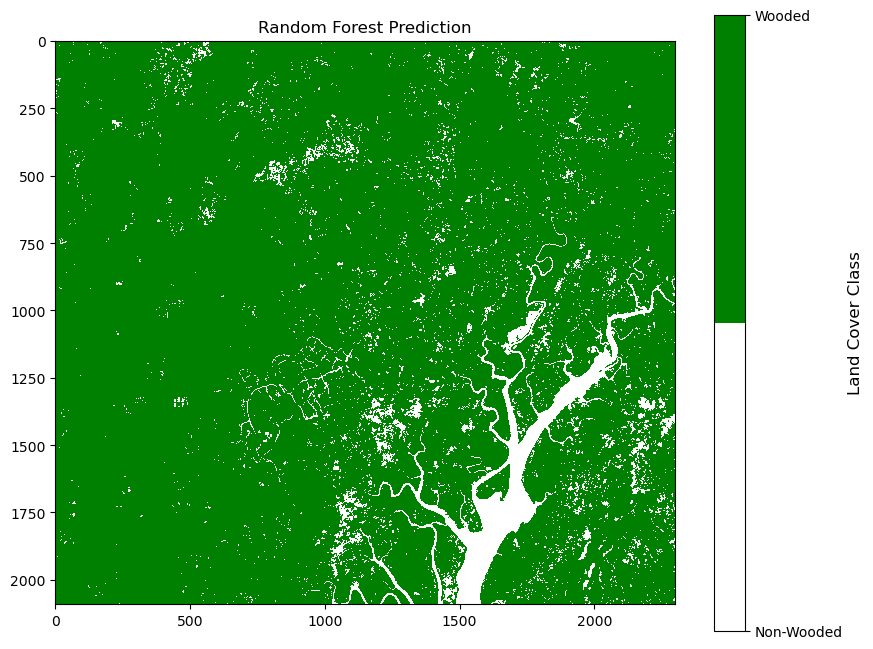

In [7]:
# Visualisasi masing-masing model
visualize_prediction("Random Forest Prediction", pred_rf)

## SVM

In [11]:
# Ganti NaN dengan nilai 0 
data_flatten = np.nan_to_num(data_flatten, nan=0.0)
# Hapus baris yang mengandung NaN
valid_mask = ~np.isnan(data_flatten).any(axis=1)
data_flatten_valid = data_flatten[valid_mask]

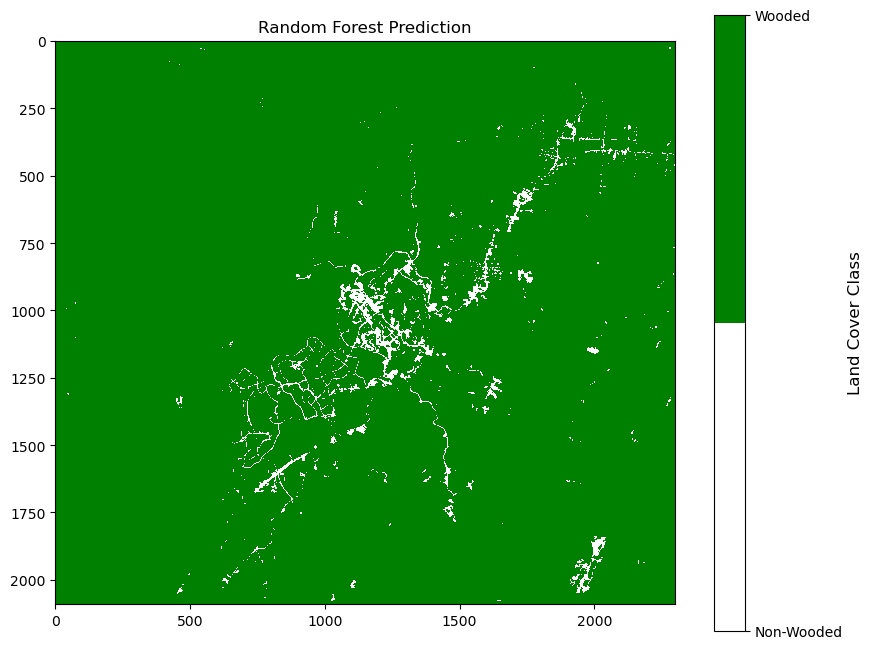

In [ ]:
# Prediksi menggunakan model
predictions_svm = model_svm.predict(data_flatten_valid)

# Reshape hasil prediksi ke dimensi asli citra
pred_svm = predictions_svm.reshape(original_shape)

#visualiasi
visualize_prediction("SVM Prediction", pred_svm)

## Gradient Boosting

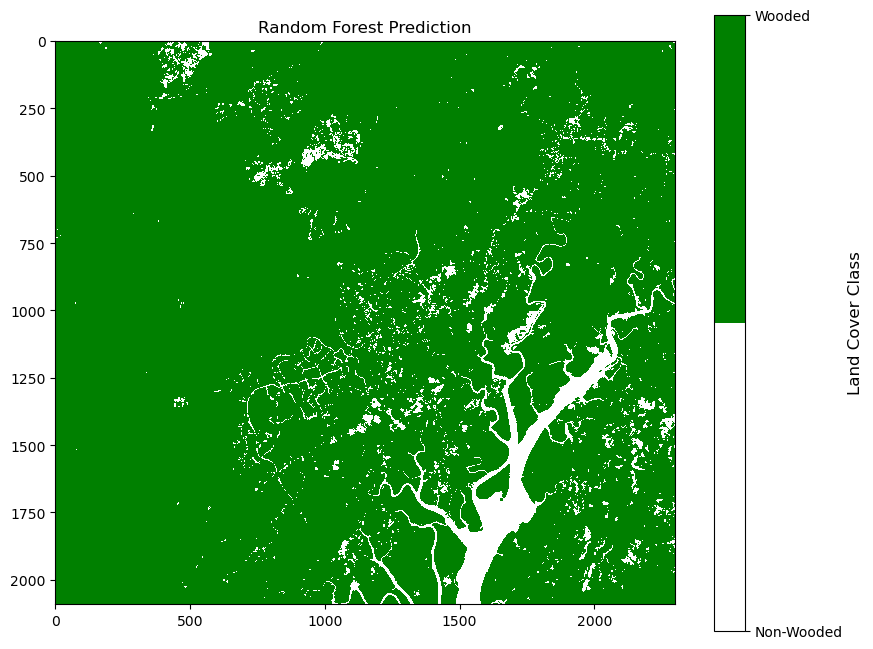

In [ ]:
# Prediksi menggunakan model
predictions_gb = model_gb.predict(data_flatten_valid)

# Reshape hasil prediksi ke dimensi asli citra
pred_gb = predictions_gb.reshape(original_shape)

#visualiasi
visualize_prediction("Gradient Boosting Prediction", pred_gb)

Naive Bayes

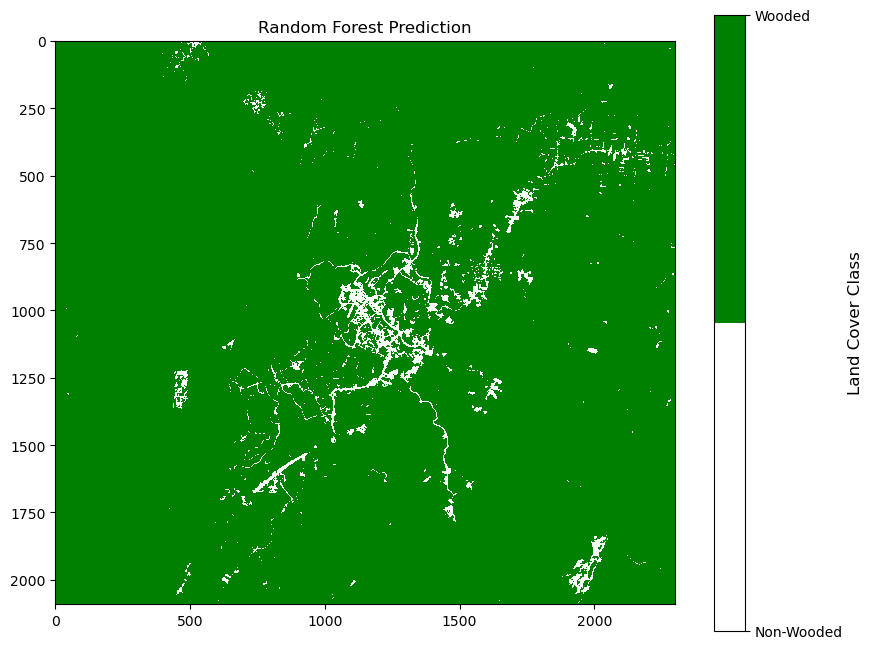

In [ ]:
# Prediksi menggunakan model
predictions_nb = model_nb.predict(data_flatten_valid)

# Reshape hasil prediksi ke dimensi asli citra
pred_nb = predictions_nb.reshape(original_shape)

#visualiasi
visualize_prediction("Naive Bayes Prediction", pred_nb)

## Ekspor Hasil Prediksi

In [15]:
# Update metadata untuk hasil prediksi
metadata.update({
    "count": 1,  # Hanya ada 1 layer (prediksi biner)
    "dtype": "uint8",  # Tipe data untuk prediksi biner
})

# Fungsi untuk menyimpan hasil ke file GeoTIFF
def save_prediction_to_tif(output_path, prediction, metadata):
    with rasterio.open(output_path, "w", **metadata) as dst:
        dst.write(prediction.astype("uint8"), 1)  # Pastikan tipe data sesuai

In [16]:
# Simpan hasil prediksi ke file GeoTIFF
save_prediction_to_tif("random_forest_prediction.tif", pred_rf, metadata)
save_prediction_to_tif("svm_prediction.tif", pred_svm, metadata)
save_prediction_to_tif("gradient_boosting_prediction.tif", pred_gb, metadata)
save_prediction_to_tif("naive_bayes_prediction.tif", pred_nb, metadata)

print("Hasil prediksi berhasil disimpan sebagai file GeoTIFF.")

Hasil prediksi berhasil disimpan sebagai file GeoTIFF.
